# ⚙️ Notebook 2: Preprocessing Pipeline

**Goal:** Prepare clean, scaled data ready for the Autoencoder.

Steps:
1. Drop irrelevant columns
2. Encode categorical features
3. Filter **benign-only** training data (critical for anomaly detection)
4. Train/Validation split
5. Scale with StandardScaler (**fit on train only** — no leakage)
6. Save processed arrays


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
train_df = pd.read_csv("../data/UNSW_NB15_training-set.csv")
test_df  = pd.read_csv("../data/UNSW_NB15_testing-set.csv")

print(f"Training set : {train_df.shape}")
print(f"Testing set  : {test_df.shape}")

Training set : (82332, 45)
Testing set  : (175341, 45)


## 1. Define Columns


In [3]:
DROP_COLS = ["id", "attack_cat", "label"]
CAT_COLS  = ["proto", "service", "state"]
TARGET    = "label"
ATK_CAT   = "attack_cat"

# Everything else is a feature
FEATURE_COLS = [c for c in train_df.columns if c not in DROP_COLS]

print(f"Feature columns  : {len(FEATURE_COLS)}")
print(f"Categorical cols : {CAT_COLS}")
print(f"Dropping         : {DROP_COLS}")

Feature columns  : 42
Categorical cols : ['proto', 'service', 'state']
Dropping         : ['id', 'attack_cat', 'label']


## 2. Check Categorical Cardinality

In [4]:
print("Cardinality of categorical columns:\n")
for col in CAT_COLS:
    n = train_df[col].nunique()
    vals = sorted(train_df[col].unique())
    preview = vals[:8]
    print(f"  {col:<10}: {n:>3} unique values → {preview}{'...' if n > 8 else ''}")

Cardinality of categorical columns:

  proto     : 131 unique values → ['3pc', 'a/n', 'aes-sp3-d', 'any', 'argus', 'aris', 'arp', 'ax.25']...
  service   :  13 unique values → ['-', 'dhcp', 'dns', 'ftp', 'ftp-data', 'http', 'irc', 'pop3']...
  state     :   7 unique values → ['ACC', 'CLO', 'CON', 'FIN', 'INT', 'REQ', 'RST']


## 3. Encode Categorical Features

Using **LabelEncoder** for all three categorical columns.
`proto` has high cardinality (~90+ values) so one-hot encoding
would add too many dimensions. LabelEncoder keeps it clean.

> ⚠️ We combine train + test before encoding to ensure
> both splits share the exact same integer mappings.

In [5]:
# Combine for consistent encoding, then split back
combined = pd.concat([train_df, test_df], ignore_index=True)

encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    combined[col] = le.fit_transform(combined[col].astype(str))
    encoders[col] = le
    print(f"✅ '{col}' encoded → {len(le.classes_)} classes")

# Split back
train_enc = combined.iloc[:len(train_df)].copy()
test_enc  = combined.iloc[len(train_df):].copy()

print(f"\nTrain encoded : {train_enc.shape}")
print(f"Test encoded  : {test_enc.shape}")

✅ 'proto' encoded → 133 classes
✅ 'service' encoded → 13 classes
✅ 'state' encoded → 11 classes

Train encoded : (82332, 45)
Test encoded  : (175341, 45)


## 4. Filter Benign-Only for Training

The Autoencoder must **only** learn from normal traffic.
We discard all attack rows from the training split.

In [6]:
# Full feature matrices
X_all_train = train_enc[FEATURE_COLS].values
y_all_train = train_enc[TARGET].values

X_test_full = test_enc[FEATURE_COLS].values
y_test      = test_enc[TARGET].values
y_test_cat  = test_enc[ATK_CAT].values

# Filter: benign only
benign_mask = y_all_train == 0
X_benign    = X_all_train[benign_mask]

print(f"Total training rows   : {len(X_all_train):,}")
print(f"Benign rows (kept)    : {len(X_benign):,}  ✅")
print(f"Attack rows (removed) : {len(X_all_train) - len(X_benign):,}  🗑️")
print(f"\n🔒 Autoencoder will train on {len(X_benign):,} benign samples only")

Total training rows   : 82,332
Benign rows (kept)    : 37,000  ✅
Attack rows (removed) : 45,332  🗑️

🔒 Autoencoder will train on 37,000 benign samples only


## 5. Train / Validation Split

In [7]:
X_train, X_val = train_test_split(
    X_benign, test_size=0.1, random_state=42
)

print(f"X_train : {X_train.shape}  (90% of benign)")
print(f"X_val   : {X_val.shape}   (10% of benign)")
print(f"X_test  : {X_test_full.shape}  (mixed — benign + attack)")

X_train : (33300, 42)  (90% of benign)
X_val   : (3700, 42)   (10% of benign)
X_test  : (175341, 42)  (mixed — benign + attack)


## 6. Scale Features — StandardScaler

> ⚠️ Critical Rule: **Fit ONLY on X_train. Transform everything else.**
> Fitting on val/test would be data leakage.

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform
X_val_scaled   = scaler.transform(X_val)          # transform only
X_test_scaled  = scaler.transform(X_test_full)    # transform only

print("✅ Scaling complete")
print(f"\nDistribution check (should be ~0 mean, ~1 std for train):")
print(f"  X_train → mean: {X_train_scaled.mean():.4f}, std: {X_train_scaled.std():.4f}")
print(f"  X_val   → mean: {X_val_scaled.mean():.4f}, std: {X_val_scaled.std():.4f}")
print(f"  X_test  → mean: {X_test_scaled.mean():.4f}, std: {X_test_scaled.std():.4f}")

✅ Scaling complete

Distribution check (should be ~0 mean, ~1 std for train):
  X_train → mean: -0.0000, std: 1.0000
  X_val   → mean: -0.0023, std: 0.9943
  X_test  → mean: 0.3276, std: 4.0500


## 7. Visualize Scaled Distributions

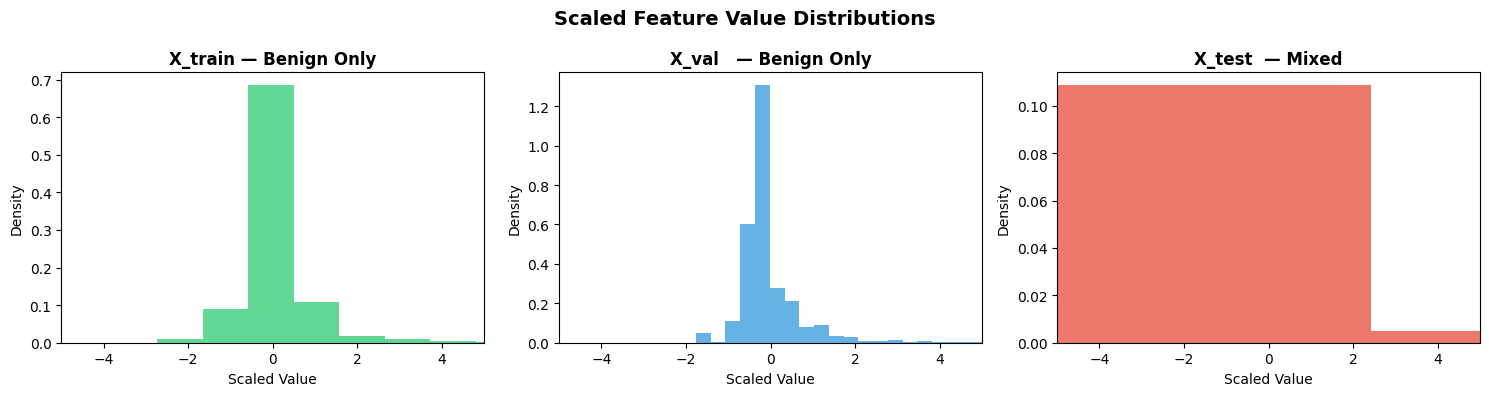

✅ Saved to outputs/figures/


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

datasets = [
    (X_train_scaled, "X_train — Benign Only", "#2ecc71"),
    (X_val_scaled,   "X_val   — Benign Only", "#3498db"),
    (X_test_scaled,  "X_test  — Mixed",       "#e74c3c"),
]

for ax, (data, title, color) in zip(axes, datasets):
    ax.hist(data.flatten(), bins=100, color=color, alpha=0.75, density=True)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Scaled Value")
    ax.set_ylabel("Density")
    ax.set_xlim(-5, 5)

plt.suptitle("Scaled Feature Value Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/02_scaled_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved to outputs/figures/")

## 8. Save All Processed Data

In [10]:
os.makedirs("../data/processed", exist_ok=True)

# Feature arrays
np.save("../data/processed/X_train.npy",       X_train_scaled)
np.save("../data/processed/X_val.npy",         X_val_scaled)
np.save("../data/processed/X_test.npy",        X_test_scaled)

# Labels & categories for evaluation
np.save("../data/processed/y_test.npy",        y_test)
np.save("../data/processed/y_test_cat.npy",    y_test_cat.astype(str))

# Feature names (needed for SHAP)
np.save("../data/processed/feature_names.npy", np.array(FEATURE_COLS))

# Scaler & encoders (needed for inverse transform)
joblib.dump(scaler,   "../data/processed/scaler.pkl")
joblib.dump(encoders, "../data/processed/encoders.pkl")

print("✅ All files saved to data/processed/\n")
print(f"  X_train.npy       : {X_train_scaled.shape}")
print(f"  X_val.npy         : {X_val_scaled.shape}")
print(f"  X_test.npy        : {X_test_scaled.shape}")
print(f"  y_test.npy        : {y_test.shape}")
print(f"  y_test_cat.npy    : {y_test_cat.shape}")
print(f"  feature_names.npy : {len(FEATURE_COLS)} features")
print(f"  scaler.pkl        : ✅")
print(f"  encoders.pkl      : ✅")

✅ All files saved to data/processed/

  X_train.npy       : (33300, 42)
  X_val.npy         : (3700, 42)
  X_test.npy        : (175341, 42)
  y_test.npy        : (175341,)
  y_test_cat.npy    : (175341,)
  feature_names.npy : 42 features
  scaler.pkl        : ✅
  encoders.pkl      : ✅


## 9. Final Summary

In [11]:
print("=" * 55)
print("        PREPROCESSING SUMMARY")
print("=" * 55)
print(f"  Total features         : {len(FEATURE_COLS)}")
print(f"  Categorical encoded    : {len(CAT_COLS)} cols (LabelEncoder)")
print(f"  Scaling                : StandardScaler (no leakage)")
print()
print(f"  X_train (benign only)  : {X_train_scaled.shape}")
print(f"  X_val   (benign only)  : {X_val_scaled.shape}")
print(f"  X_test  (mixed)        : {X_test_scaled.shape}")
print()
print(f"  Benign in test set     : {(y_test == 0).sum():,}")
print(f"  Attack in test set     : {(y_test == 1).sum():,}")
print("=" * 55)
print("✅ Ready for Autoencoder training!")

        PREPROCESSING SUMMARY
  Total features         : 42
  Categorical encoded    : 3 cols (LabelEncoder)
  Scaling                : StandardScaler (no leakage)

  X_train (benign only)  : (33300, 42)
  X_val   (benign only)  : (3700, 42)
  X_test  (mixed)        : (175341, 42)

  Benign in test set     : 56,000
  Attack in test set     : 119,341
✅ Ready for Autoencoder training!
